Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Used to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Used to bring all features to a similar scale
from sklearn.preprocessing import StandardScaler

# Our machine learning model
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

Load Dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Dataset doesn't contain column names, so we provide them ourselves
columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(url, header=None, names=columns)#header=none, Because the original dataset does not contain column names.

# Check whether the dataset loaded correctly
df.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Basic Exploration

In [3]:
# Shows (rows, columns)
print(df.shape)

# Shows column names, data types, and non-null values
df.info()

# Gives mean, standard deviation, min, max, median, etc.
df.describe()

(569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

,ID,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Missing Values

In [4]:
# Counts missing values in every column
df.isnull().sum()

,0
ID,0
Diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0


Duplicates

In [5]:
# Counts completely duplicate rows
df.duplicated().sum()

np.int64(0)

Class Distribution

In [6]:
# Counts Benign (B) and Malignant (M) cases
df["Diagnosis"].value_counts()

,count
Diagnosis,
B,357
M,212


In [7]:
# Shows the class distribution as percentages
df["Diagnosis"].value_counts(normalize=True) * 100

,proportion
Diagnosis,
B,62.741652
M,37.258348


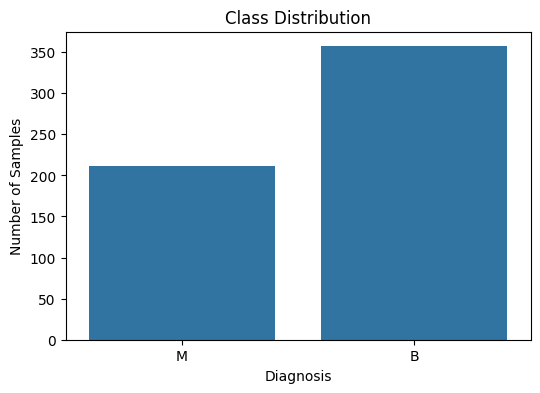

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Diagnosis")

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

Box plots

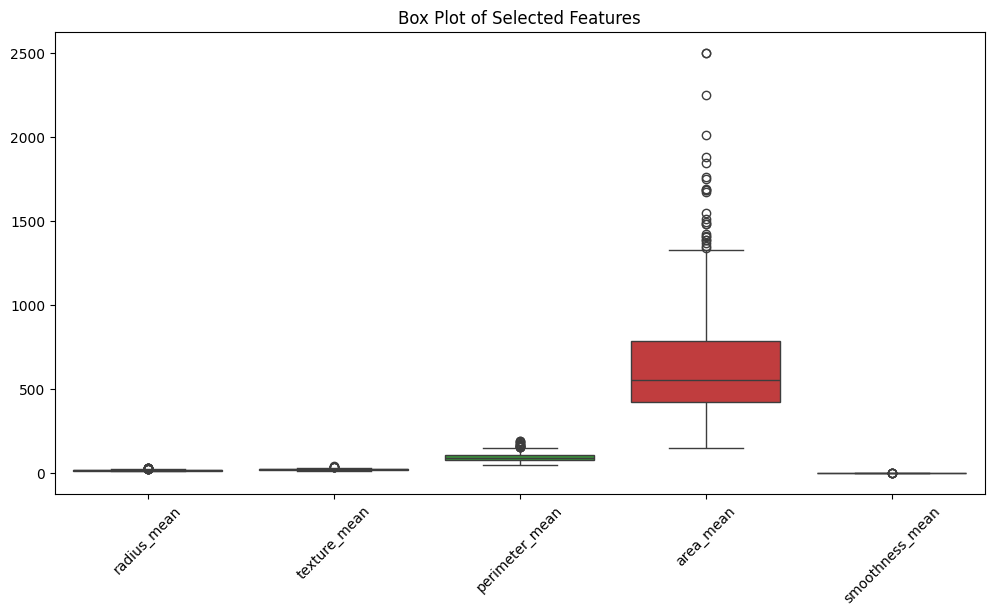

In [9]:
# Select some important numerical features
features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean"
]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[features])

plt.title("Box Plot of Selected Features")
plt.xticks(rotation=45)

plt.show()

Detect outliers using IQR

In [10]:
# Calculate the number of potential outliers in each numerical feature
Q1 = df.drop(columns=["ID", "Diagnosis"]).quantile(0.25)
Q3 = df.drop(columns=["ID", "Diagnosis"]).quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df.drop(columns=["ID", "Diagnosis"]) < lower_bound) |
    (df.drop(columns=["ID", "Diagnosis"]) > upper_bound)
).sum()

print("Potential outliers in each feature:")
display(outliers)

Potential outliers in each feature:


,0
radius_mean,14
texture_mean,7
perimeter_mean,13
area_mean,25
smoothness_mean,6
compactness_mean,16
concavity_mean,18
concave_points_mean,10
symmetry_mean,15
fractal_dimension_mean,15


Calculate correlation between numerical features

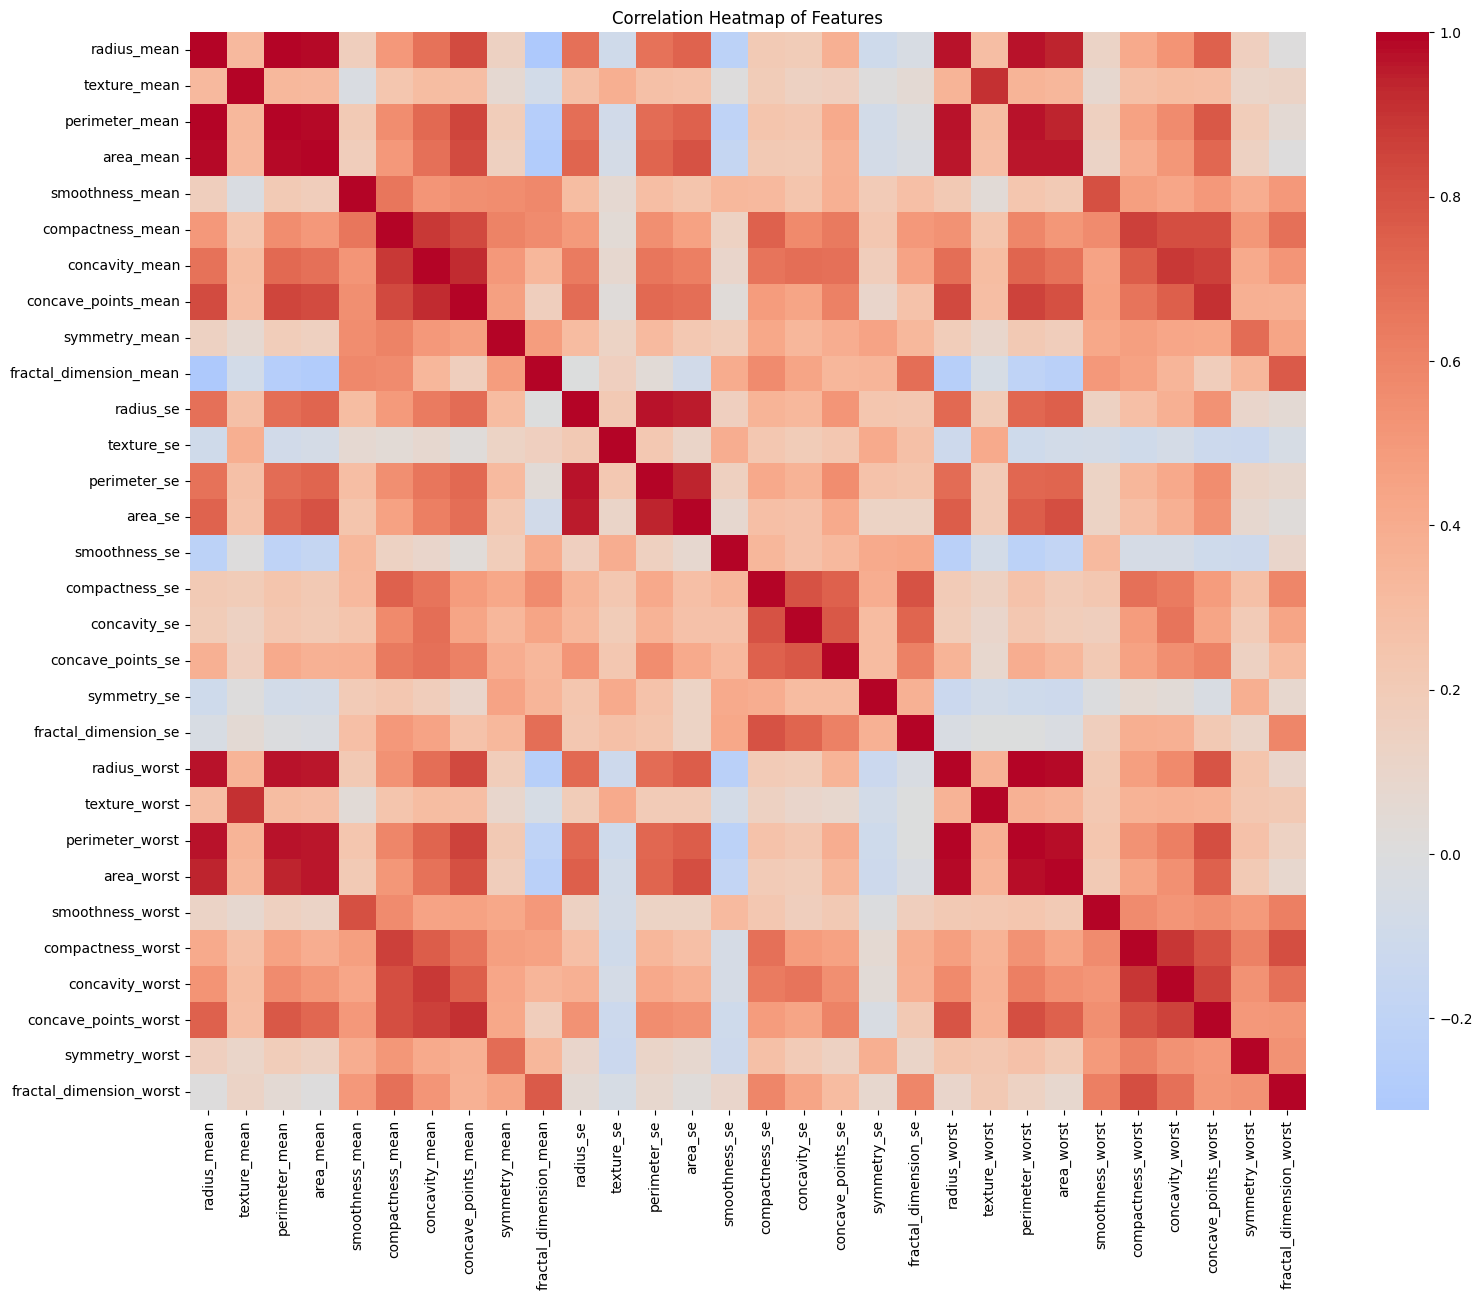

In [31]:
# Calculate correlation between numerical features
correlation_matrix = df.drop(columns=["ID", "Diagnosis"]).corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Features")
plt.show()
#blue showing negagive correlation
#white=zlose to zero
#blue=negative

Encode the target

In [11]:
# Convert diagnosis into binary values
df["Diagnosis"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

df["Diagnosis"].value_counts()

,count
Diagnosis,
0,357
1,212


Separate features and target

In [12]:
# X contains the input features
# y contains the answer we want the model to predict
X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"]

Train/Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y     #it is used for mainting same ratio of split in train and test
)

Standardize the features

In [15]:
# Create the scaler
scaler = StandardScaler()

# Learn the scaling parameters from training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same parameters to transform test data
X_test_scaled = scaler.transform(X_test)

Check the scaled data

In [16]:
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


Train Logistic Regression

In [17]:
# Create the Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the training data
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Make predictions

In [18]:
# Predict the diagnosis for the test samples
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


Accuracy

In [19]:
# Calculate the percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


Precision, Recall and F1

In [20]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.975
Recall: 0.9285714285714286
F1-score: 0.9512195121951219


Metrics for both classes

In [21]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Confusion Matrix

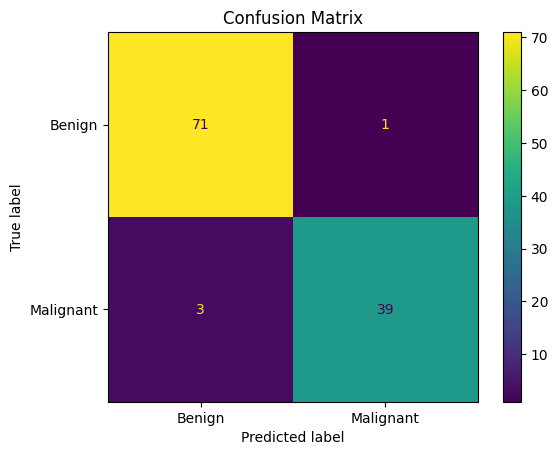

In [22]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it with class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

Get prediction probabilities

In [23]:
# Get probability of each class
y_prob = model.predict_proba(X_test_scaled)[:, 1]

Calculate ROC and AUC

In [24]:
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate Area Under the ROC Curve
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.996031746031746


Plot ROC Curve

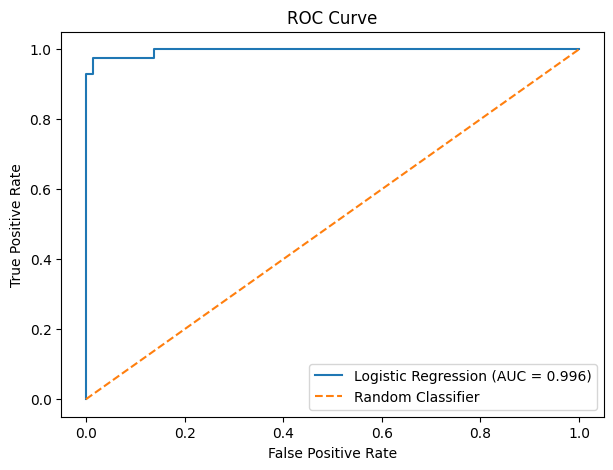

In [25]:
plt.figure(figsize=(7, 5))

# Plot our Logistic Regression ROC curve
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

# This represents a random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

Create one final results table

In [26]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

display(results)

,Metric,Score
0,Accuracy,0.964912
1,Precision,0.975000
2,Recall,0.928571
3,F1-Score,0.951220
4,ROC-AUC,0.996032


One more useful visualization: feature coefficients

In [27]:
# Get the learned coefficient for every feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Sort by the absolute size of the coefficient
coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficients.head(10))

,Feature,Coefficient,Absolute_Coefficient
21,texture_worst,1.434093,1.434093
10,radius_se,1.233325,1.233325
28,symmetry_worst,1.061264,1.061264
7,concave_points_mean,0.952813,0.952813
26,concavity_worst,0.911406,0.911406
13,area_se,0.909029,0.909029
15,compactness_se,-0.906925,0.906925
23,area_worst,0.900477,0.900477
20,radius_worst,0.896968,0.896968
6,concavity_mean,0.782298,0.782298


Final Conclusion

In [28]:

print("Logistic Regression was successfully trained and evaluated.")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")
print(f"ROC-AUC  : {auc_score:.3f}")

Logistic Regression was successfully trained and evaluated.
Accuracy : 0.965
Precision: 0.975
Recall   : 0.929
F1-Score : 0.951
ROC-AUC  : 0.996
